In [5]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = plt.cm.viridis
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

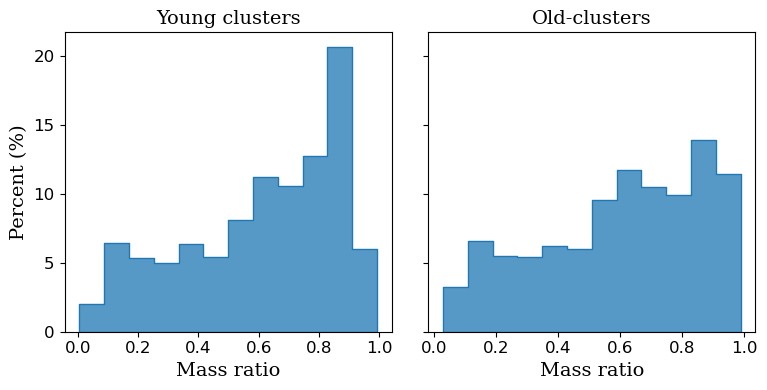

In [7]:
def classificar_idade(age):
    return 'Young clusters' if age < 8 else 'Old-clusters'

aux = data.copy(deep=True)
aux = aux[aux.q > 0]
aux['age_group'] = aux['age'].apply(classificar_idade)


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins=12)
    axs[i].set_title(age_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
plt.savefig('Figures/hist_mass_ratio_mass.png', bbox_inches='tight', dpi=300)
plt.show()


In [15]:
#Compara as distribuições da razão de massa dos dois subconjuntos

young_q = aux[aux.age_group == 'Young clusters']['q']
old_q = aux[aux.age_group == 'Old-clusters']['q']

# Kolmogorov–Smirnov test
ks_stat, ks_p = ks_2samp(young_q, old_q)
print(f"KS test: stat = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')
    
# Mann–Whitney U test    
u_stat, u_p = mannwhitneyu(young_q, old_q, alternative='two-sided')
print(f"Mann–Whitney U test: U = {u_stat:.4f}, p = {u_p:.4f}")

if u_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')

# Anderson–Darling test  
result = anderson_ksamp([young_q, old_q])
print(f"Anderson–Darling test: stat = {result.statistic:.4f}, p = {result.significance_level:.4f}")
if result.significance_level < 5: 
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')



KS test: stat = 0.0528, p = 0.0000
Distribuições distintas

Mann–Whitney U test: U = 813092259.0000, p = 0.0039
Distribuições distintas

Anderson–Darling test: stat = 144.3620, p = 0.0010
Distribuições distintas



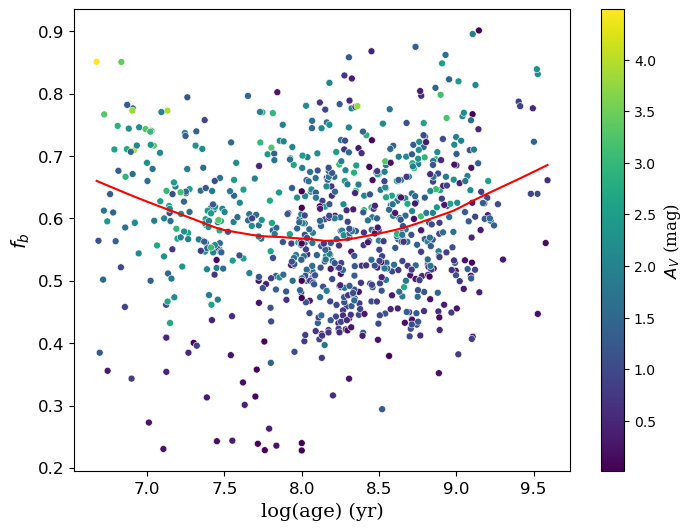

In [26]:
fig, ax = plt.subplots(figsize=(8,6))

sc = sns.scatterplot(data=df, x='age', y='bin_frac', hue='Av', palette=palette, legend=False, ax=ax, s=25)

lowess = sm.nonparametric.lowess
y_smoothed = lowess(df.bin_frac, df.age, frac=0.4)
ax.plot(y_smoothed[:,0], y_smoothed[:,1], color='red',)

norm = mpl.colors.Normalize(
    vmin=df['Av'].min(skipna=True),
    vmax=df['Av'].max(skipna=True)
)

cm_ = mpl.cm.ScalarMappable(norm=norm, cmap=palette)
cm_.set_array([])

cbar = fig.colorbar(cm_, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)

plt.savefig('Figures/dist_fb_age.png', bbox_inches='tight', dpi=300)
plt.show()


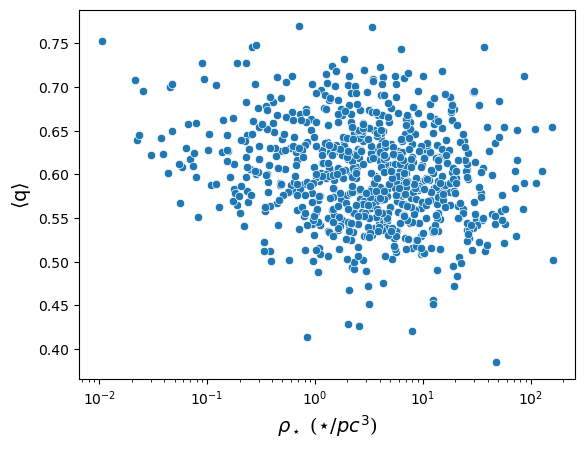

In [6]:
c = 4 * np.pi / 3
V = c*df['rh']**3
density = df['n_members']/V
q_mean = []
for cluster in df.index:
    q_mean.append(data[data.q>0].loc[cluster, 'q'].mean())

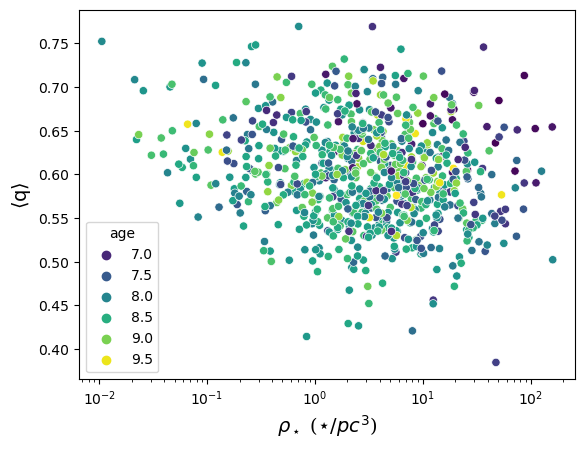

In [9]:
sns.scatterplot(x=density,y=q_mean,hue=df['age'], palette=palette)
plt.xscale('log')
plt.xlabel(r'$\rho_\star$ ($\star/pc^3$)', fontdict=font)
plt.ylabel(r"$\langle \mathrm{q} \rangle$", fontdict=font)

plt.show()